# Storage, Hydro, and Transmission

## (I) Land Eligibility for Wind Turbines

Eligibility analysis for the land area available for the development of wind parks in the Grand Duchy of Luxembourg.
    
The following areas are to be excluded or included:
1. Exclusion of natural protection areas
2. Exclusion of a radius of 5 km around airports
3. Exclusion of a buffer of 500m next to major roads
4. Exclusion of a distance of 1200m around the following CORINE land cover classes: 111, 112, 121, 133, 141, 142
5. Inclusion only of the following CORINE land cover classes, which are deemed suitable for constructing wind turbines: 211, 212, 231, 241, 243, 321, 323, 324, 333        

#### Import relevant packages

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs

import rasterio
from rasterio.plot import show
from atlite.gis import ExclusionContainer
from atlite.gis import shape_availability

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore") 

import requests
from bs4 import BeautifulSoup
import csv

#### Translate CORINE land classes to code values

In [2]:
# URL of the webpage containing the table
url_corine_dataset = 'https://collections.sentinel-hub.com/corine-land-cover/readme.html'

# Send a GET request to the webpage

response = requests.get(url_corine_dataset)
response.raise_for_status()  # Check that the request was successful

# Parse the HTML content using BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')

# Find all tables on the webpage
tables = soup.find_all('table')

# Select the second table (index 1)
table = tables[1]

# Extract table headers
headers = [header.text for header in table.find_all('th')]

# Extract table rows
rows = []
for row in table.find_all('tr'):
    cells = row.find_all('td')
    cells = [cell.text for cell in cells]
    if cells:  # Only add rows that have data
        rows.append(cells)

# Create a DataFrame from the extracted table data
corine_land_cover_dataset = pd.DataFrame(rows, columns=headers)
corine_land_cover_dataset['Land Classes'] = corine_land_cover_dataset['Label'].str[:3]
corine_land_cover_dataset['Descriptive Names'] = corine_land_cover_dataset['Label'].str[6:]
corine_land_cover_dataset.drop(columns = ['Label', 'Color', 'Color Code'], inplace= True)
corine_land_cover_dataset.rename(columns = {'Value' : 'Code Values'}, inplace = True)


# Display full dataset
corine_land_cover_dataset.head()

,Code Values,Land Classes,Descriptive Names
0,1,111,Continuous urban fabric
1,2,112,Discontinuous urban fabric
2,3,121,Industrial or commercial units
3,4,122,Road and rail networks and associated land
4,5,123,Port areas


In [3]:
# Filter the DataFrame based on the given corine land classes

corine_land_classes = [111,112,121,133,141,142,211,212,231,241,243,321,323,324,333]
df_corine_land_classes = corine_land_cover_dataset[corine_land_cover_dataset['Land Classes'].astype(int).isin(corine_land_classes)]

df_corine_land_classes = df_corine_land_classes.reset_index(drop = True)

# Display DataFrame
df_corine_land_classes

,Code Values,Land Classes,Descriptive Names
0,1,111,Continuous urban fabric
1,2,112,Discontinuous urban fabric
2,3,121,Industrial or commercial units
3,9,133,Construction sites
4,10,141,Green urban areas
5,11,142,Sport and leisure facilities
6,12,211,Non-irrigated arable land
7,13,212,Permanently irrigated land
8,18,231,Pastures
9,19,241,Annual crops associated with permanent crops


In [4]:
# Distinguish between types of land classes
exclusion_land_cover_classes =  [111, 112, 121,133, 141, 142]
eligible_wind_development_classes =  [211, 212, 231, 241, 243, 321, 323, 324, 333]

df_corine_land_classes['Class Type'] = ''
for i in range(len(df_corine_land_classes)):
    land_class = int(df_corine_land_classes['Land Classes'].iloc[i])
    if land_class in exclusion_land_cover_classes:
        df_corine_land_classes.at[i,'Class Type'] = 'Keep distance / buffer'
    else:
        df_corine_land_classes.at[i,'Class Type'] = 'Eligible for wind development'

# Display DataFrame
df_corine_land_classes

,Code Values,Land Classes,Descriptive Names,Class Type
0,1,111,Continuous urban fabric,Keep distance / buffer
1,2,112,Discontinuous urban fabric,Keep distance / buffer
2,3,121,Industrial or commercial units,Keep distance / buffer
3,9,133,Construction sites,Keep distance / buffer
4,10,141,Green urban areas,Keep distance / buffer
5,11,142,Sport and leisure facilities,Keep distance / buffer
6,12,211,Non-irrigated arable land,Eligible for wind development
7,13,212,Permanently irrigated land,Eligible for wind development
8,18,231,Pastures,Eligible for wind development
9,19,241,Annual crops associated with permanent crops,Eligible for wind development


#### Load country shapes as GeoDataFrame

In [5]:
url_country_shapes = "https://tubcloud.tu-berlin.de/s/7bpHrAkjMT3ADSr/download/country_shapes.geojson"

# GeoDataFrame
countries = gpd.read_file(url_country_shapes).set_index("name")

print(countries.head())

                                               geometry
name                                                   
AE    MULTIPOLYGON (((56.34002 25.60456, 56.34799 25...
AF    POLYGON ((74.54235 37.02167, 74.54742 37.01567...
AL    POLYGON ((20.56715 41.87318, 20.54172 41.86158...
AM    POLYGON ((45.03940 41.23118, 45.02932 41.21010...
AO    MULTIPOLYGON (((23.98058 -10.93835, 24.00001 -...


In [6]:
# Reduce shapes to Luxembourg
luxembourg = countries.loc[['LU']]

# Reproject to crs EPSG:3035
luxembourg = luxembourg.to_crs(3035)

<GeoAxes: >

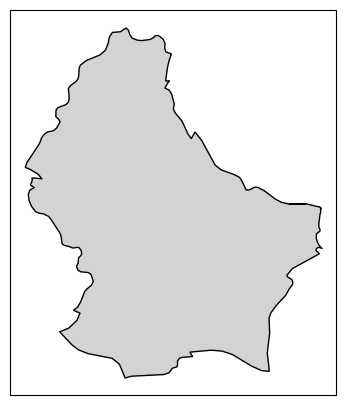

In [7]:
# Plot luxembourg
crs = ccrs.EqualEarth()
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=crs)

luxembourg.to_crs(crs.proj4_init).plot(ax=ax, edgecolor="k", facecolor="lightgrey")

#### Plot and calculate (in %) the area excluded by each of the exclusion constraints individually

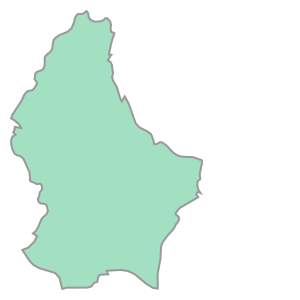

In [8]:
# Extract shape of Luxembourg directly since both are the same crs of EPSG:3035
shape_luxembourg = luxembourg.geometry
shape_luxembourg.iloc[0]


 Natural protection areas exclude 24.19% leaving 75.81% eligible land.


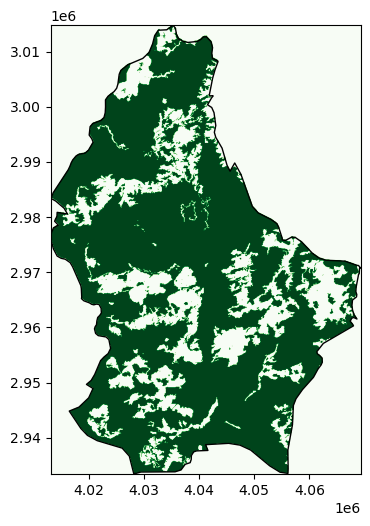

In [9]:
# Initialize single exclusion container
excluder1 = ExclusionContainer(crs=3035)

# Exclusion of natural protection areas
url_natural_protection_areas = 'https://tubcloud.tu-berlin.de/s/zPMqJFPD8tKq2Ss/download/Natura2000_end2021-LU.gpkg'
excluder1.add_geometry(url_natural_protection_areas)

# Shape availability
band, transform = shape_availability(shape_luxembourg, excluder1)

# Plot available area
fig, ax = plt.subplots(figsize=(4, 8))
shape_luxembourg.plot(ax=ax, color="none")
show(band, transform=transform, cmap="Greens", ax=ax)

# Area excluded and eligible Land
eligible_cells = band.sum()
cell_area = excluder1.res**2
eligible_area = cell_area * eligible_cells
country_area = shape_luxembourg.geometry.area.iloc[0]
excluded_area = country_area - eligible_area

# Display results
print(f"\n Natural protection areas exclude {excluded_area / country_area * 100:.2f}% leaving {(eligible_area / country_area * 100):.2f}% eligible land.")


 Airport(s)(buffer:5km) exclude 3.01% leaving 96.99% eligible land.


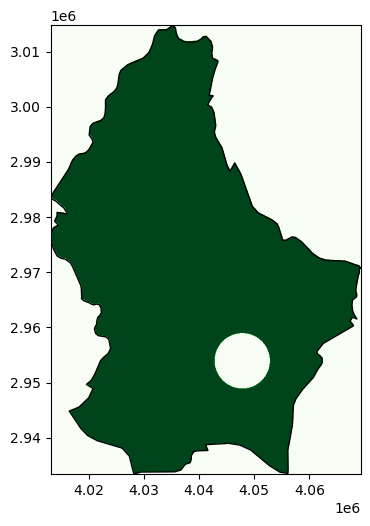

In [10]:
# Initialize single exclusion container
excluder2 = ExclusionContainer(crs = 3035)

# Exclusion of a radius of 5 km around airports
url_exclusion_radius_5km_airports = 'https://tubcloud.tu-berlin.de/s/TbEJ9Lsy9EpTcQS/download/ne_10m_airports.gpkg'
excluder2.add_geometry(url_exclusion_radius_5km_airports, buffer = 5000)

# Shape availability
band, transform = shape_availability(shape_luxembourg, excluder2)

# Plot available area
fig, ax = plt.subplots(figsize=(4, 8))
shape_luxembourg.plot(ax=ax, color="none")
show(band, transform=transform, cmap="Greens", ax=ax)

# Area excluded and eligible Land
eligible_cells = band.sum()
cell_area = np.int64(excluder2.res**2)
eligible_area = cell_area * eligible_cells
country_area = shape_luxembourg.geometry.area.iloc[0]
excluded_area = country_area - eligible_area

# Display results
print(f"\n Airport(s)(buffer:5km) exclude {excluded_area / country_area * 100:.2f}% leaving {(eligible_area / country_area * 100):.2f}% eligible land.")

Major roads(buffer:500m) exclude 51.56% leaving 48.44% eligible land.


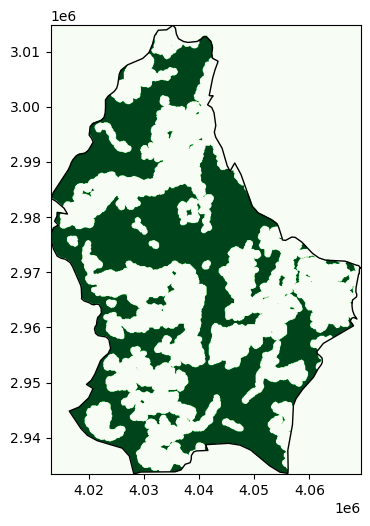

In [11]:
# Initialize single exclusion container
excluder3 = ExclusionContainer(crs = 3035)

# Exclusion of a buffer of 500m next to major roads
url_exclusion_buffer_500m_roads = 'https://tubcloud.tu-berlin.de/s/zcKQ95TgpyMJb8E/download/ne_10m_roads.gpkg'
excluder3.add_geometry(url_natural_protection_areas, buffer = 500)

# Shape availability
band, transform = shape_availability(shape_luxembourg, excluder3)

# Plot available area
fig, ax = plt.subplots(figsize=(4, 8))
shape_luxembourg.plot(ax=ax, color="none")
show(band, transform=transform, cmap="Greens", ax=ax)

# Area excluded and eligible Land
eligible_cells = band.sum()
cell_area = excluder3.res**2
eligible_area = cell_area * eligible_cells
country_area = shape_luxembourg.geometry.area.iloc[0]
excluded_area = country_area - eligible_area

# Display results
print(f"Major roads(buffer:500m) exclude {excluded_area / country_area * 100:.2f}% leaving {(eligible_area / country_area * 100):.2f}% eligible land.")

Continuous urban fabric, Discontinuous urban fabric, Industrial or commercial units, Construction sites, Green urban areas, Sport and leisure facilities exclude 68.31% leaving 48.44% eligible land.


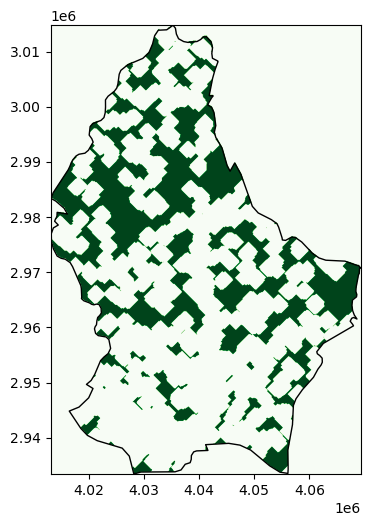

In [12]:
# Initialize exclusion container
excluder4 = ExclusionContainer(crs = 3035)

# Exclusion of a distance of 1200m around the following CORINE land cover classes: 111, 112, 121,133, 141, 142
url_exclusion_1200m_land_cover = 'https://tubcloud.tu-berlin.de/s/z7aY8HNCdETQMT7/download/U2018_CLC2018_V2020_20u1-LU.tif'

# Extract code values from corine land cover dataset
codes_exclusion_list = df_corine_land_classes[df_corine_land_classes['Class Type'] == 'Keep distance / buffer']['Code Values'].to_list()
codes_excluded = [int(code) for code in codes_exclusion_list]

excluder4.add_raster(url_exclusion_1200m_land_cover, codes = codes_excluded, buffer = 1200, crs = 3035)

# Shape availability
band, transform = shape_availability(shape_luxembourg, excluder4)

# Plot available area
fig, ax = plt.subplots(figsize=(4, 8))
shape_luxembourg.plot(ax=ax, color="none")
show(band, transform=transform, cmap="Greens", ax=ax)

# Area excluded and eligible Land
eligible_cells = band.sum()
cell_area = excluder4.res**2
eligible_area2 = cell_area * eligible_cells
country_area = shape_luxembourg.geometry.area.iloc[0]
excluded_area = country_area - eligible_area2

# List of excluded areas
land_cover_exclusion_list = df_corine_land_classes[df_corine_land_classes['Class Type'] == 'Keep distance / buffer']['Descriptive Names'].to_list()

# Display results
print(f"{', '.join(str(item) for item in land_cover_exclusion_list)} exclude {excluded_area / country_area * 100:.2f}% leaving {(eligible_area / country_area * 100):.2f}% eligible land.")

Non-irrigated arable land, Permanently irrigated land, Pastures, Annual crops associated with permanent crops, Land principally occupied by agriculture with significant areas of natural vegetation, Natural grasslands, Sclerophyllous vegetation, Transitional woodland-shrub, Sparsely vegetated areas exclude 60.56% leaving 39.44% eligible land.


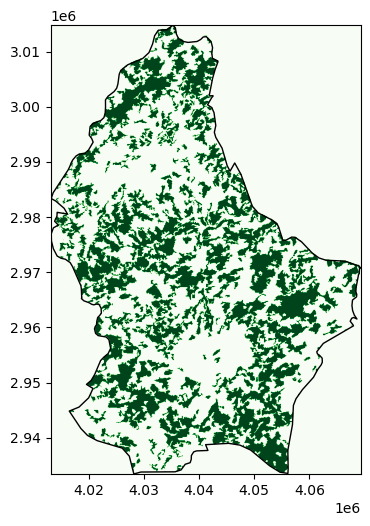

In [13]:
# Initialize exclusion container
excluder5 = ExclusionContainer(crs = 3035)

# Inclusion only of the following CORINE land cover classes, which are deemed suitable for constructing wind turbines: 211, 212, 231, 241, 243, 321, 323, 324, 333
url_inclusion_wind_turbine = 'https://tubcloud.tu-berlin.de/s/z7aY8HNCdETQMT7/download/U2018_CLC2018_V2020_20u1-LU.tif'

# Extract code values from corine land cover dataset
codes_inclusion_list = df_corine_land_classes[df_corine_land_classes['Class Type'] == 'Eligible for wind development']['Code Values'].to_list()
codes_included = [int(code) for code in codes_inclusion_list]

excluder5.add_raster(url_inclusion_wind_turbine, codes = codes_included, crs = 3035, invert = True)

# Shape availability
band, transform = shape_availability(shape_luxembourg, excluder5)

# Plot available area
fig, ax = plt.subplots(figsize=(4, 8))
shape_luxembourg.plot(ax=ax, color="none")
show(band, transform=transform, cmap="Greens", ax=ax)

# Area excluded and eligible Land
eligible_cells = band.sum()
cell_area = excluder5.res**2
eligible_area = cell_area * eligible_cells
country_area = shape_luxembourg.geometry.area.iloc[0]
excluded_area = country_area - eligible_area

# List of eligible land included
eligible_land_inclusion_list = df_corine_land_classes[df_corine_land_classes['Class Type'] == 'Eligible for wind development']['Descriptive Names'].to_list()

# Display results
print(f"{', '.join(str(item) for item in eligible_land_inclusion_list)} exclude {excluded_area / country_area * 100:.2f}% leaving {(eligible_area / country_area * 100):.2f}% eligible land.")

#### Plot and calculate (in %) the area available for the development of wind parks considering all exclusion and inclusion criteria together

Natural protection areas, Airports (buffer:5km), Major roads(buffer:500m), Continuous urban fabric, Discontinuous urban fabric, Industrial or commercial units, Construction sites, Green urban areas, Sport and leisure facilities, Non-irrigated arable land, Permanently irrigated land, Pastures, Annual crops associated with permanent crops, Land principally occupied by agriculture with significant areas of natural vegetation, Natural grasslands, Sclerophyllous vegetation, Transitional woodland-shrub, Sparsely vegetated areas exclude 90.90% leaving 9.10% eligible land.


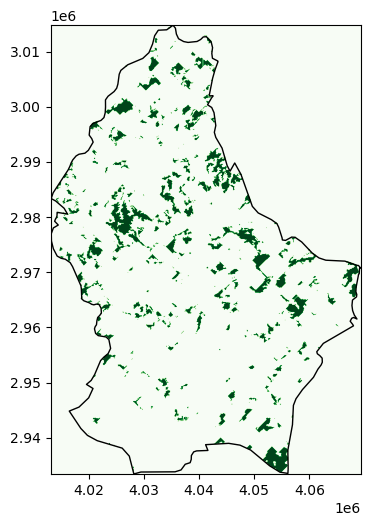

In [14]:
# Initialize combined exclusion container
excluder = ExclusionContainer(crs = 3035)

# Add all exclusion/inclusion areas to Exclusion container
excluder.add_geometry(url_natural_protection_areas)
excluder.add_geometry(url_exclusion_radius_5km_airports)
excluder.add_geometry(url_exclusion_buffer_500m_roads)
excluder.add_raster(url_exclusion_1200m_land_cover, codes = codes_excluded, buffer = 1200, crs = 3035)
excluder.add_raster(url_inclusion_wind_turbine, codes_included, crs = 3035, invert = True)

# Shape availability
band, transform = shape_availability(shape_luxembourg, excluder)

# Plot available area
fig, ax = plt.subplots(figsize=(4, 8))
shape_luxembourg.plot(ax=ax, color="none")
show(band, transform=transform, cmap="Greens", ax=ax)

# Area excluded and eligible Land
eligible_cells = band.sum()
cell_area = excluder.res**2
eligible_area = cell_area * eligible_cells
country_area = shape_luxembourg.geometry.area.iloc[0]
excluded_area = country_area - eligible_area

# Display results
print(f"Natural protection areas, Airports (buffer:5km), Major roads(buffer:500m), {', '.join(str(item) for item in land_cover_exclusion_list)}, {', '.join(str(item) for item in eligible_land_inclusion_list)} exclude {excluded_area / country_area * 100:.2f}% leaving {(eligible_area / country_area * 100):.2f}% eligible land.")

#### Sensitivity Analysis

In [15]:
# Initialize combined exclusion container
excluder6 = ExclusionContainer(crs = 3035)

# Exclusion of distances around the following CORINE land cover classes: 111, 112, 121,133, 141, 142
url_exclusion_land_cover = 'https://tubcloud.tu-berlin.de/s/z7aY8HNCdETQMT7/download/U2018_CLC2018_V2020_20u1-LU.tif'

eligible_areas = []
distance_requirements = [0, 200, 400, 600, 800, 1000, 1200]
for distance in distance_requirements:

    # Add all exclusion/inclusion areas to Exclusion container
    excluder6.add_geometry(url_natural_protection_areas)
    excluder6.add_geometry(url_exclusion_radius_5km_airports)
    excluder6.add_geometry(url_exclusion_buffer_500m_roads)
    excluder6.add_raster(url_exclusion_land_cover, codes = codes_excluded, buffer = distance, crs = 3035)
    excluder6.add_raster(url_inclusion_wind_turbine, codes_included, crs = 3035, invert = True)

    # Shape availability
    band, transform = shape_availability(shape_luxembourg, excluder6)
    
    # Eligible Land area
    eligible_cells = band.sum()
    cell_area = excluder6.res**2
    eligible_area = cell_area * eligible_cells
    
    # Append the result to the eligible_areas list
    eligible_areas.append(eligible_area)

# Print the eligible_areas list
print(eligible_areas)

[841000000, 652690000, 545530000, 448460000, 364230000, 294470000, 237450000]


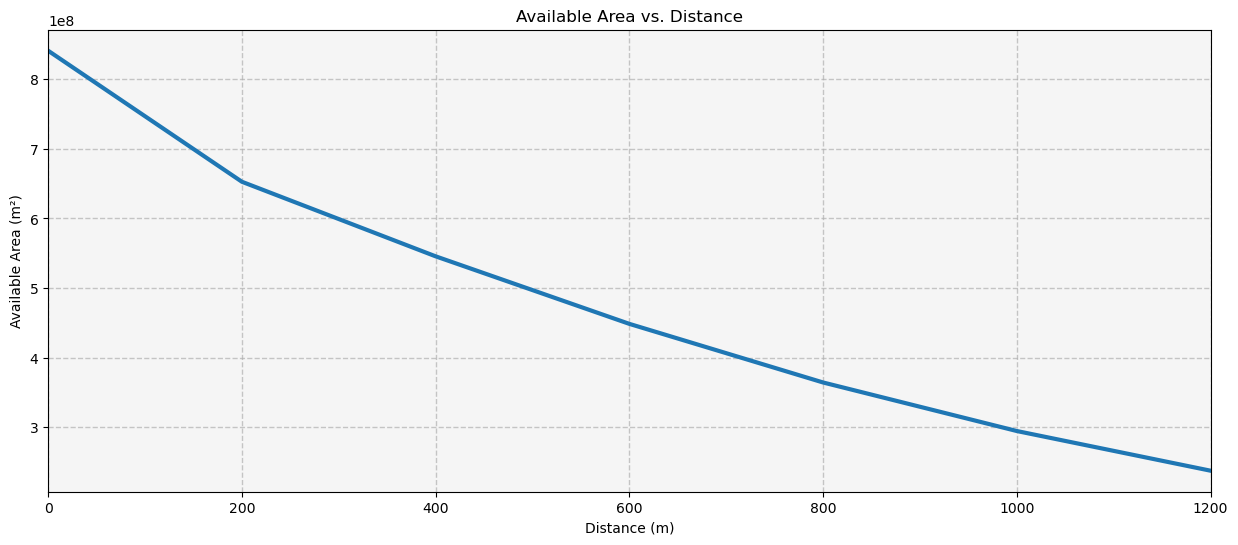

In [16]:
# Plot the available area (in %) as a function of the distance requirements
plt.figure(figsize=(15,6)).add_subplot().set_facecolor('whitesmoke')
plt.plot(distance_requirements, eligible_areas,linewidth = 3)
plt.xlabel('Distance (m)')
plt.ylabel('Available Area (m²)')
plt.title('Available Area vs. Distance')
plt.grid(linestyle='--', linewidth=1, alpha=0.7)
plt.xlim(0, max(distance_requirements))

# Display plot
plt.show()

##### Describe the Curve 
As the distance requirements increase there's a drop in the available area for development

#### Total energy in units of TWh potentially produced from wind power in Luxembourg each year with a distance criterion of 800m

In [17]:
capacity_density = 5 # MW/km^2
capacity_factor = 0.32 
eligible_area_distance_criterion_800m = eligible_areas[distance_requirements.index(800)] / (10**6) # km^2
hours_in_year = 8760

total_energy = capacity_density * capacity_factor * eligible_area_distance_criterion_800m * hours_in_year / (10**6)
print(f"The potential total energy in Luxembourg each year with a distance crierion of 800m from the selected CORINE land classes is {total_energy:.2f} TWh.")


The potential total energy in Luxembourg each year with a distance crierion of 800m from the selected CORINE land classes is 5.11 TWh.


## (II) Dimensioning Loseless Storage

Using the time series on wind and solar capacity factors and electricity demand in Germany in 2015

The goal of this task is to dimension a lossless storage for different generation mixes of onshore wind and solar to supply demand.

#### Scaled Capacity Factor for Onshore Wind and Solar

In [18]:
# Load dataset into dataframe
url_time_series = "https://tubcloud.tu-berlin.de/s/ppRkB2mwsKkJrRm/download/time-series-lecture-2.csv"
df_time_series = pd.read_csv(url_time_series, index_col=0, parse_dates=True)
print(df_time_series.columns)

# Drop unused_columns
df_time_series.drop(columns = ['offwind [pu]', 'prices [€/MWh]'], inplace = True)
df_time_series.head()

Index(['load [GW]', 'onwind [pu]', 'offwind [pu]', 'solar [pu]',
       'prices [€/MWh]'],
      dtype='object')


,load [GW],onwind [pu],solar [pu]
2015-01-01 00:00:00,41.151,0.1566,0.0
2015-01-01 01:00:00,40.135,0.1659,0.0
2015-01-01 02:00:00,39.106,0.1746,0.0
2015-01-01 03:00:00,38.765,0.1745,0.0
2015-01-01 04:00:00,38.941,0.1826,0.0


In [19]:
# Onwind time series scaled

df_time_series["onwind [GW]"] = df_time_series["onwind [pu]"]/df_time_series["onwind [pu]"].sum()*df_time_series["load [GW]"].sum()

# Solar time series scaled
df_time_series["solar [GW]"] = df_time_series["solar [pu]"]/df_time_series["solar [pu]"].sum()*df_time_series["load [GW]"].sum()

# Display results
df_time_series.head()

,load [GW],onwind [pu],solar [pu],onwind [GW],solar [GW]
2015-01-01 00:00:00,41.151,0.1566,0.0,41.700539,0.0
2015-01-01 01:00:00,40.135,0.1659,0.0,44.177008,0.0
2015-01-01 02:00:00,39.106,0.1746,0.0,46.493705,0.0
2015-01-01 03:00:00,38.765,0.1745,0.0,46.467076,0.0
2015-01-01 04:00:00,38.941,0.1826,0.0,48.624000,0.0


#### Assert sum of each column are equal to load [GW]

In [20]:
assert df_time_series['load [GW]'].sum().round(2) == df_time_series['onwind [GW]'].sum().round(2) and df_time_series['load [GW]'].sum().round(2) == df_time_series['solar [GW]'].sum().round(2), f"Condition 1 failed: Condition 2 failed:"

print("Both conditions are satisfied, their sums are equal to the load [GW]")

Both conditions are satisfied, their sums are equal to the load [GW]


#### Residual Load Time series

In [21]:
# Residual time series with 100% wind supplied
df_time_series["residual_load_wind [GW]"] = df_time_series["load [GW]"] - df_time_series["onwind [GW]"]

# Residual time series with  100% solar supplied
df_time_series["residual_load_solar [GW]"] = df_time_series["load [GW]"] - df_time_series["solar [GW]"]

# Display results
df_time_series[["residual_load_wind [GW]","residual_load_solar [GW]",]].head().round(2)

,residual_load_wind [GW],residual_load_solar [GW]
2015-01-01 00:00:00,-0.55,41.15
2015-01-01 01:00:00,-4.04,40.14
2015-01-01 02:00:00,-7.39,39.11
2015-01-01 03:00:00,-7.70,38.76
2015-01-01 04:00:00,-9.68,38.94


#### Plot the two residual load time series for June in a single figure.

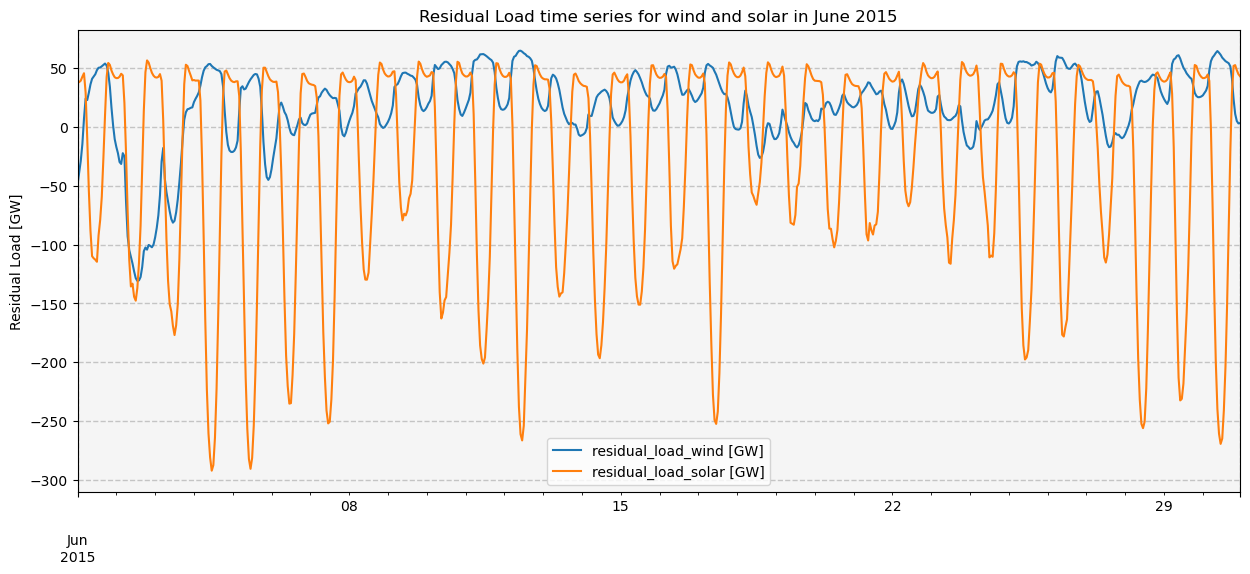

In [22]:
# Plot Residual Load for both wind and solar

df_time_series.loc["2015 -06-01 00:00:00":"2015 -06-30 23:00:00", "residual_load_wind [GW]":"residual_load_solar [GW]"].plot(title ="Residual Load time series for wind and solar in June 2015", ylabel="Residual Load [GW]",figsize=(15,6)).set_facecolor('whitesmoke')
plt.grid(linestyle='--', linewidth=1, alpha=0.7)


#### State of charge profiles

##### SOC for 100% wind generation

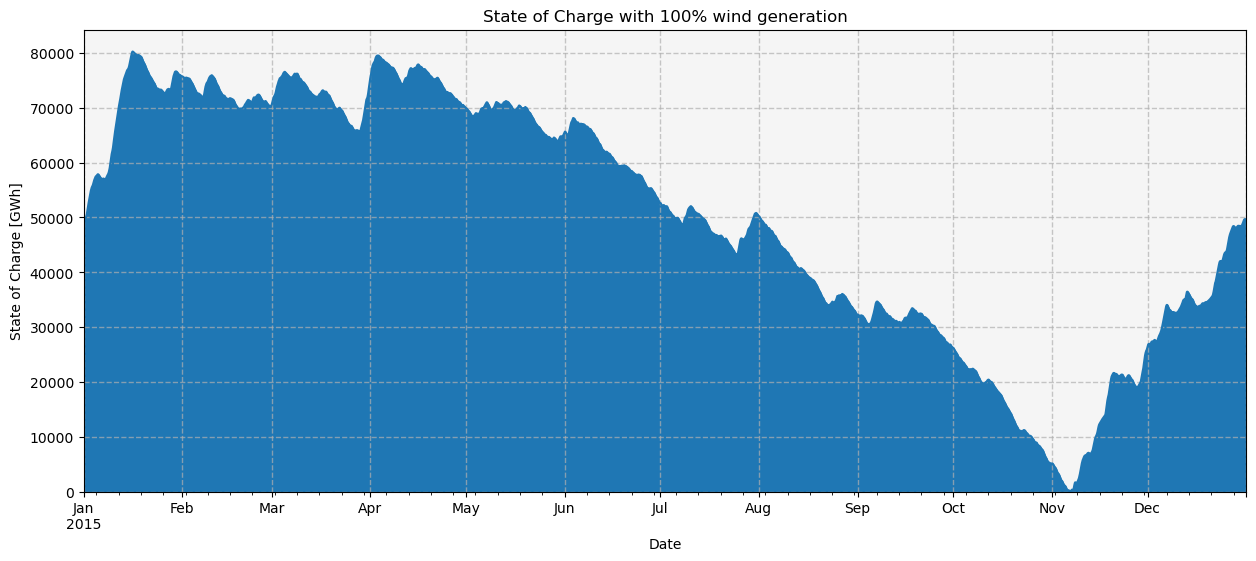

In [23]:
# Compute cumulative sum of excess and shortage
df_time_series['SOC_wind [GWh]'] = -1 * df_time_series['residual_load_wind [GW]'].cumsum() 

# Compute offset
offset_wind = abs(df_time_series['SOC_wind [GWh]'].min())

# Update State of Charge with offset to remove negative values
df_time_series['SOC_wind [GWh]'] = df_time_series['SOC_wind [GWh]'] + offset_wind

plt.figure(figsize=(15, 6)).add_subplot().set_facecolor('whitesmoke')
df_time_series['SOC_wind [GWh]'].plot.area(title='State of Charge with 100% wind generation')

plt.xlabel('Date')
plt.ylabel('State of Charge [GWh]')
plt.grid(linestyle='--', linewidth=1, alpha=0.7)
plt.show()

##### SOC for 100% solar generation

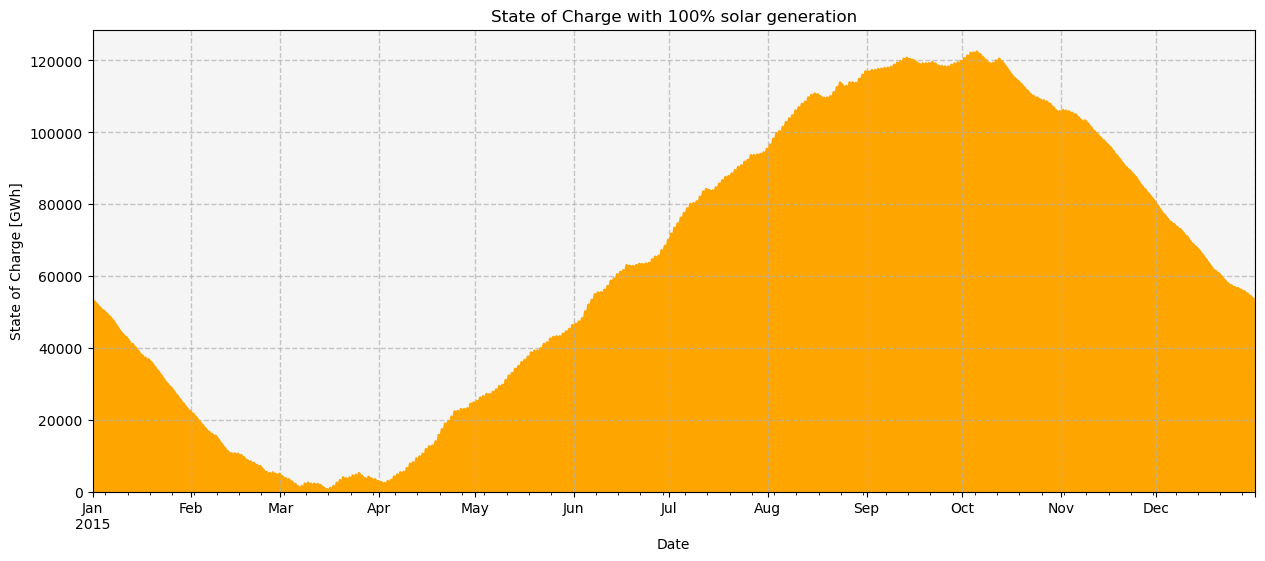

In [24]:
# Compute cumulative sum of excess and shortage
df_time_series['SOC_solar [GWh]'] = -1 * df_time_series['residual_load_solar [GW]'].cumsum() 

# Compute offset
offset_solar = abs(df_time_series['SOC_solar [GWh]'].min())

# Update State of Charge with offset to remove negative values
df_time_series['SOC_solar [GWh]'] = df_time_series['SOC_solar [GWh]'] + offset_solar

plt.figure(figsize=(15, 6)).add_subplot().set_facecolor('whitesmoke')
df_time_series['SOC_solar [GWh]'].plot.area(title='State of Charge with 100% solar generation',color='orange')
plt.xlabel('Date')
plt.ylabel('State of Charge [GWh]')
plt.grid(linestyle='--', linewidth=1, alpha=0.7)

plt.show()

#### Required energy [GWh], charge [GW], discharge [GW] capacities for a purely wind based and a purely solar-based system

In [25]:
# Compute required energy, required charge and discharge capacities for 100% wind
energy_wind  = df_time_series['SOC_wind [GWh]'].max()
wind_charge_capacity = -1 * df_time_series[["residual_load_wind [GW]"]].min().iloc[0]
wind_discharge_capacity = -1 * df_time_series[["residual_load_wind [GW]"]].max().iloc[0]

# Compute required energy, required charge and discharge capacities for 100% solar
energy_solar  = df_time_series['SOC_solar [GWh]'].max()
solar_charge_capacity = -1 * df_time_series[["residual_load_solar [GW]"]].min().iloc[0]
solar_discharge_capacity =-1 *  df_time_series[["residual_load_solar [GW]"]].max().iloc[0]

# Create dataframe to display results
# Create dictionary of lists
capacities_summary_dict = {'Required Energy [GWh]': [energy_wind,energy_solar],
                     'Charge capacity [GW]': [wind_charge_capacity,solar_charge_capacity],
                     'Discharge capacity [GW]': [wind_discharge_capacity,solar_discharge_capacity]}

# Specify index
capacities_summary_index = ['Wind','Solar']

# Use pandas with specified index and dictionary to create dataframe
df_capacities = pd.DataFrame(capacities_summary_dict, index=capacities_summary_index)

# Round values to two decimal places
df_capacities.round(2)

,Required Energy [GWh],Charge capacity [GW],Discharge capacity [GW]
Wind,80278.35,202.28,-68.40
Solar,122497.96,300.04,-75.82


##### Identification of capacities
 - The energy required is the maximum State of Charge.
   
 - Since the residual load  = load - variable energy generation,  the excess generation yield negative values while charging and shortage generation yield positive values while discharging.

 -  The charge capacity is the minimum value of the residual load time series.

 -  The discharge capacity is the maximum value of the residual load time series.

#### Python Function for computing residual load with mixed generation

In [26]:
# Function returning residual load for mixed technology of wind and solar
def residual_load_mix(𝛼, df):
    wind_generation_share = 𝛼
    solar_generation_share =  1 - 𝛼
    residual_load  = df["load [GW]"] - (wind_generation_share * df["onwind [GW]"]) - (solar_generation_share * df["solar [GW]"])
    return residual_load

#### Apply this function for steps of 5% between 0% and 100% for 𝛼 and store the residual load time series in a pandas.DataFrame

In [28]:
# Initialize DataFrame
df_residual_load  = pd.DataFrame()

# Loop through values of 𝛼 and apply function ot calculate residual load
for 𝛼 in range(0, 101, 5):
    𝛼 = 𝛼/100 # Convert to float
    df_residual_load[f'residual_load_alpha_{𝛼*100:.0f}%'] = residual_load_mix(𝛼, df_time_series)

# Display results
df_residual_load.iloc[:5,:5]

,residual_load_alpha_0%,residual_load_alpha_5%,residual_load_alpha_10%,residual_load_alpha_15%,residual_load_alpha_20%
2015-01-01 00:00:00,41.151,39.065973,36.980946,34.895919,32.810892
2015-01-01 01:00:00,40.135,37.926150,35.717299,33.508449,31.299598
2015-01-01 02:00:00,39.106,36.781315,34.456630,32.131944,29.807259
2015-01-01 03:00:00,38.765,36.441646,34.118292,31.794939,29.471585
2015-01-01 04:00:00,38.941,36.509800,34.078600,31.647400,29.216200


In [29]:
for 𝛼 in range(0, 101, 5):
    𝛼 = 𝛼/100 # Convert to float
    df_residual_load[f'residual_load_alpha_{𝛼*100:.0f}%'] = residual_load_mix(𝛼, df_time_series)

##### Check that the cases of 𝛼  = 0 and 𝛼 = 1 correspond with 100% solar generation and 100% wind generation respectively

In [30]:
assert (df_time_series['residual_load_solar [GW]'].round(2) == df_residual_load['residual_load_alpha_0%'].round(2)).all(), "Condition 1 failed"

assert (df_time_series['residual_load_wind [GW]'].round(2) == df_residual_load['residual_load_alpha_100%'].round(2)).all(), "Condition 2 failed"

print("Both conditions are satisfied, the values correspond.")


Both conditions are satisfied, the values correspond.


#### Plot of required storage charge and discharge capacities as a finction of wind generation share 𝛼

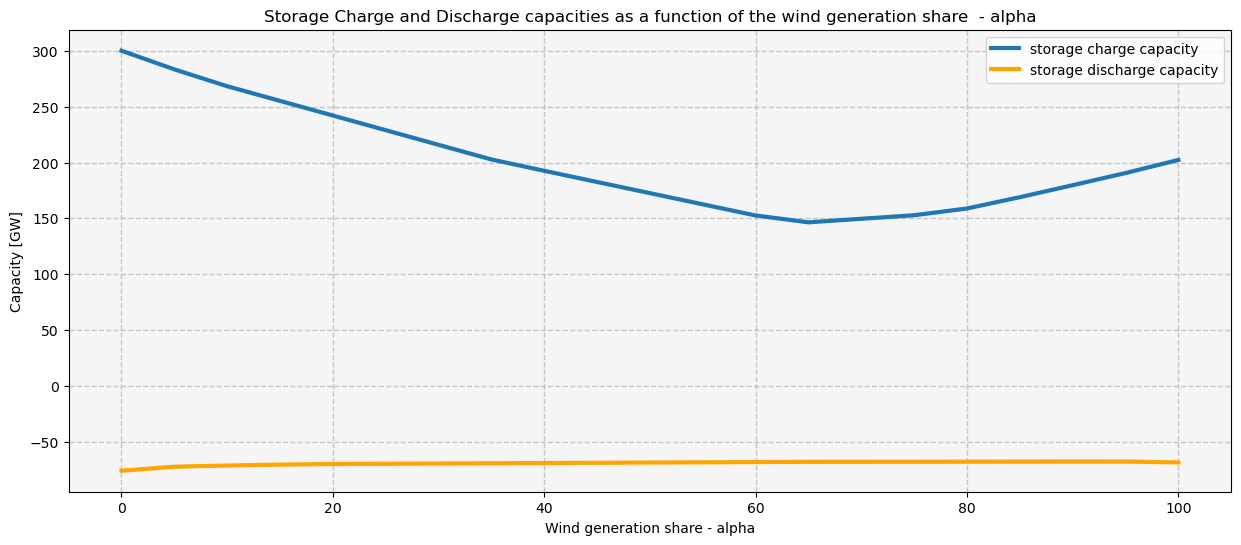

In [31]:
# Compute charge and discharge capacities
storage_charge_capacities = -1 * df_residual_load.iloc[:,:21].min()
storage_discharge_capacities = -1 * df_residual_load.iloc[:,:21].max()

# Wind generation share - 𝛼
𝛼 = [i for i in range(0, 101, 5)]

# Plotting
plt.figure(figsize=(15, 6)).add_subplot().set_facecolor('whitesmoke')
plt.plot(𝛼, storage_charge_capacities, label='storage charge capacity',linewidth=3)
plt.plot(𝛼, storage_discharge_capacities, label='storage discharge capacity',color='orange',linewidth=3)

# Adding labels and legend
plt.ylabel('Capacity [GW]')
plt.xlabel('Wind generation share - alpha')
plt.title('Storage Charge and Discharge capacities as a function of the wind generation share  - alpha')
plt.legend()
plt.grid(linestyle='--', linewidth=1, alpha=0.7)

# Displaying the plot
plt.show()


#### Plot the required energy capacity of a storage

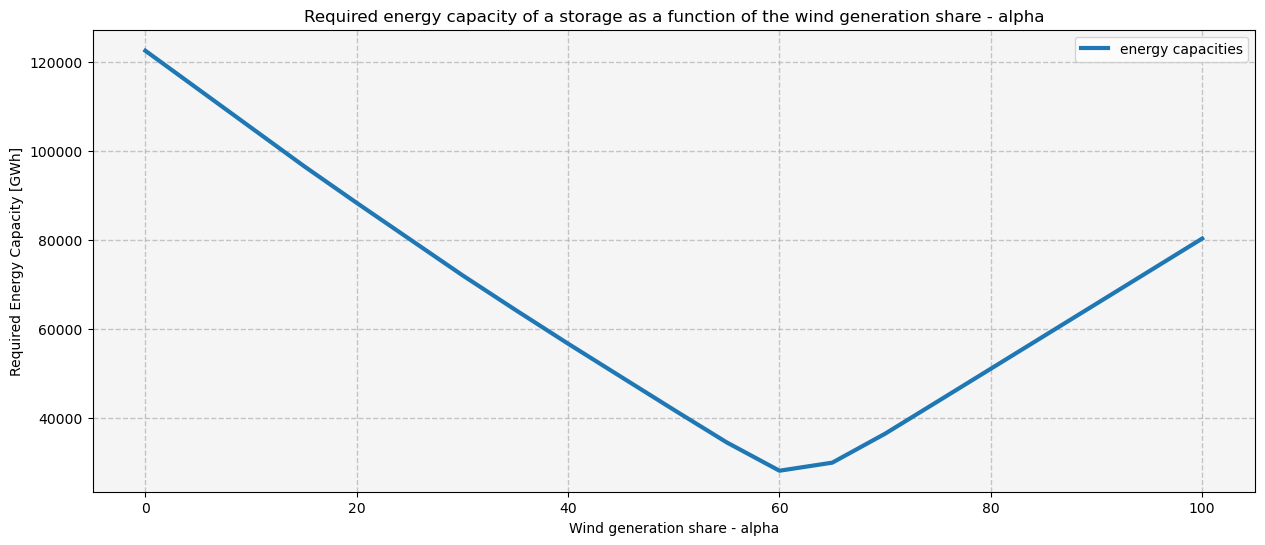

In [32]:
# Compute State of Charge for mixed variable renewable energy generaton
for col in df_residual_load.columns:
    # Remove negative values
    offset = abs((-1*df_residual_load[col]).cumsum().min())
    df_residual_load[f"SOC{col[13:]}"] =  (-1*df_residual_load[col]).cumsum() + offset

# Extract only State of charge columns from dataframe
energy_capacities = df_residual_load.iloc[:, 21:].max()

# Wind generation share - 𝛼
𝛼 = [i for i in range(0, 101, 5)]

# Plotting
plt.figure(figsize=(15, 6)).add_subplot().set_facecolor('whitesmoke')
plt.plot(𝛼, energy_capacities[:21], label='energy capacities', linewidth = 3)

# Adding labels and legend
plt.ylabel('Required Energy Capacity [GWh]')
plt.xlabel('Wind generation share - alpha')
plt.title('Required energy capacity of a storage as a function of the wind generation share - alpha')
plt.legend()
plt.grid(linestyle='--', linewidth=1, alpha=0.7)

# Displaying the plot
plt.show()


#### 𝛼 with lowest energy capacity required for the storage

In [33]:
optimal_𝛼 = str(energy_capacities.idxmin())[-3:]
print(f"The optimal value of 𝛼 is {optimal_𝛼}, requiring the lowest energy capacity of storage.")

The optimal value of 𝛼 is 60%, requiring the lowest energy capacity of storage.


#### State of charge profile for optimal 𝛼 and compare it to the cases with 100% wind or solar

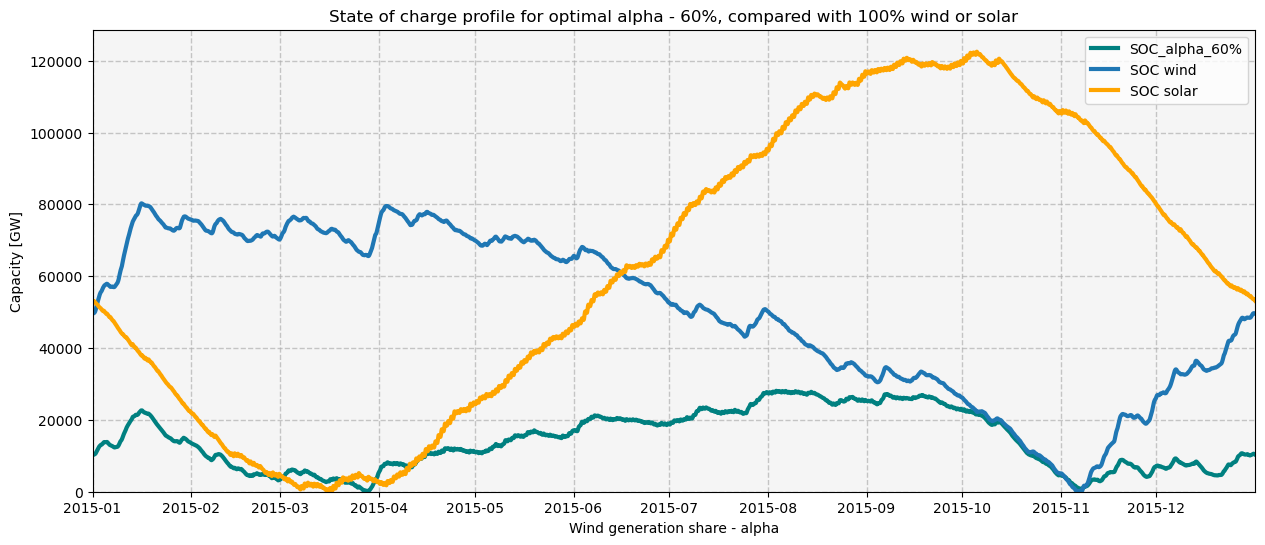

In [34]:
# Wind generation share - 𝛼
𝛼 = [i for i in range(0, 101, 5)]

# Plotting
plt.figure(figsize=(15, 6)).add_subplot().set_facecolor('whitesmoke')
plt.plot(df_time_series.loc["2015 -01-01 00:00:00":"2015 -12-31 23:00:00"].index, df_residual_load['SOC_alpha_60%'], label='SOC_alpha_60%',color = 'teal',linewidth=3)
plt.plot(df_time_series.loc["2015 -01-01 00:00:00":"2015 -12-31 23:00:00"].index, df_time_series['SOC_wind [GWh]'], label='SOC wind',linewidth=3)
plt.plot(df_time_series.loc["2015 -01-01 00:00:00":"2015 -12-31 23:00:00"].index, df_time_series['SOC_solar [GWh]'], label='SOC solar',color='orange',linewidth=3)

# Adding labels and legend
plt.ylabel('Capacity [GW]')
plt.xlabel('Wind generation share - alpha')
plt.title('State of charge profile for optimal alpha - 60%, compared with 100% wind or solar')
plt.legend()
plt.xlim(df_time_series.loc["2015 -01-01 00:00:00":"2015 -12-31 23:00:00"].index.min(), df_time_series.loc["2015 -01-01 00:00:00":"2015 -12-31 23:00:00"].index.max())
plt.ylim(0)
plt.grid(linestyle='--', linewidth=1, alpha=0.7)

# Displaying the plot
plt.show()

#### Effect of additional load on wind and solar generation share required to minimize storage capacity

In [35]:
# Half of mean the original load profile
time_series_half_mean = (df_time_series['load [GW]'].mean())/2

# Equate values as per question
mean = time_series_half_mean
amplitude = time_series_half_mean
# Compute additional load

additional_load_time_series = pd.Series(mean + amplitude
* np.cos(2 * np.pi * df_time_series.index.dayofyear / 365), index=df_time_series.index)

# Initialize solar and wind capacity factors
df_new_time_series = df_time_series[['solar [pu]', 'onwind [pu]']]

# Incluse additional load profile
df_new_time_series['load [GW]'] = df_time_series['load [GW]'] + additional_load_time_series
df_new_time_series.head()

,solar [pu],onwind [pu],load [GW]
2015-01-01 00:00:00,0.0,0.1566,95.883937
2015-01-01 01:00:00,0.0,0.1659,94.867937
2015-01-01 02:00:00,0.0,0.1746,93.838937
2015-01-01 03:00:00,0.0,0.1745,93.497937
2015-01-01 04:00:00,0.0,0.1826,93.673937


##### Scale new time series

In [36]:
# Onwind time series scaled

df_new_time_series["onwind [GW]"] = df_new_time_series["onwind [pu]"]/df_new_time_series["onwind [pu]"].sum()*df_new_time_series["load [GW]"].sum()

# Solar time series scaled
df_new_time_series["solar [GW]"] = df_new_time_series["solar [pu]"]/df_new_time_series["solar [pu]"].sum()*df_new_time_series["load [GW]"].sum()

# Display results
df_new_time_series.head()

,solar [pu],onwind [pu],load [GW],onwind [GW],solar [GW]
2015-01-01 00:00:00,0.0,0.1566,95.883937,62.550809,0.0
2015-01-01 01:00:00,0.0,0.1659,94.867937,66.265512,0.0
2015-01-01 02:00:00,0.0,0.1746,93.838937,69.740557,0.0
2015-01-01 03:00:00,0.0,0.1745,93.497937,69.700614,0.0
2015-01-01 04:00:00,0.0,0.1826,93.673937,72.936001,0.0


##### Calculate new residual load for mixed VRE

In [37]:
# Initialize DataFrame
df_new_residual_load  = pd.DataFrame()

# Loop through values of 𝛼 and apply function and calculate residual load
for 𝛼 in range(0, 101, 5):
    𝛼 = 𝛼/100 # Convert to float
    df_new_residual_load[f'residual_load_alpha_{𝛼*100:.0f}%'] = residual_load_mix(𝛼, df_new_time_series)

# Display results
df_new_residual_load.iloc[:5,:5]

,residual_load_alpha_0%,residual_load_alpha_5%,residual_load_alpha_10%,residual_load_alpha_15%,residual_load_alpha_20%
2015-01-01 00:00:00,95.883937,92.756396,89.628856,86.501315,83.373775
2015-01-01 01:00:00,94.867937,91.554661,88.241386,84.928110,81.614834
2015-01-01 02:00:00,93.838937,90.351909,86.864881,83.377853,79.890825
2015-01-01 03:00:00,93.497937,90.012906,86.527875,83.042845,79.557814
2015-01-01 04:00:00,93.673937,90.027137,86.380337,82.733537,79.086737


##### SOC for new time series

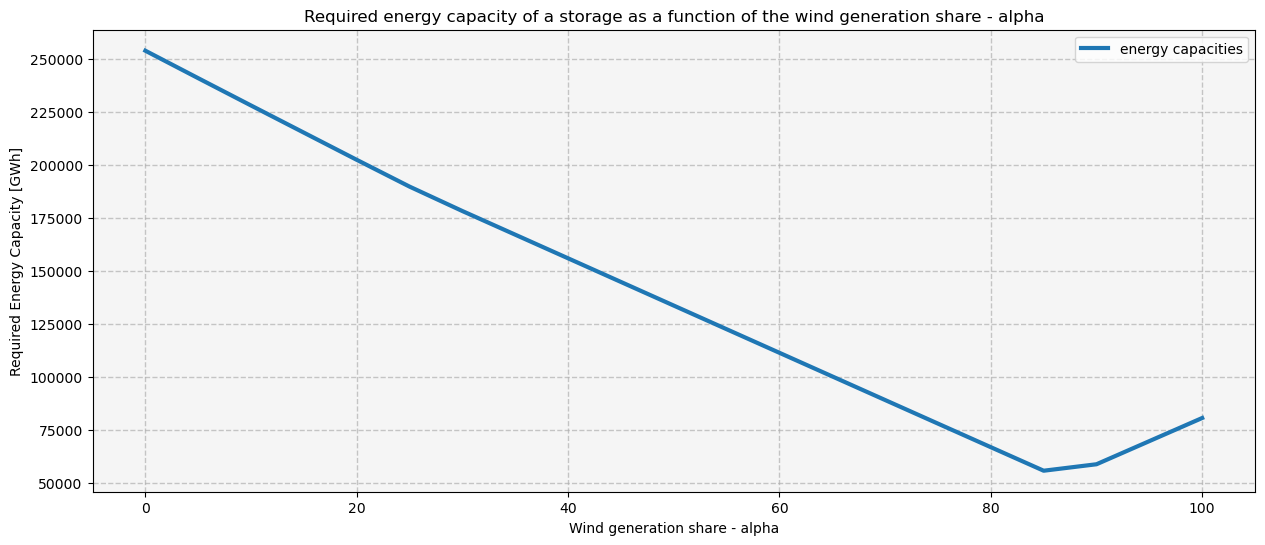

In [38]:
# Compute State of Charge for mixed variable renewable energy generaton
for col in df_new_residual_load.columns:
    # Remove negative values
    offset = abs((-1*df_new_residual_load[col]).cumsum().min())
    df_new_residual_load[f"SOC{col[13:]}"] =  (-1*df_new_residual_load[col]).cumsum() + offset

# Extract only State of charge columns from dataframe
new_energy_capacities = df_new_residual_load.iloc[:, 21:].max()

# Wind generation share - 𝛼
𝛼 = [i for i in range(0, 101, 5)]

# Plotting
plt.figure(figsize=(15, 6)).add_subplot().set_facecolor('whitesmoke')
plt.plot(𝛼, new_energy_capacities[:21], label='energy capacities', linewidth = 3)

# Adding labels and legend
plt.ylabel('Required Energy Capacity [GWh]')
plt.xlabel('Wind generation share - alpha')
plt.title('Required energy capacity of a storage as a function of the wind generation share - alpha')
plt.legend()
plt.grid(linestyle='--', linewidth=1, alpha=0.7)

# Displaying the plot
plt.show()

##### New optimal alpha

In [39]:
new_optimal_𝛼 = str(new_energy_capacities.idxmin())[-3:]
print(f"The optimal value of 𝛼 is {new_optimal_𝛼}, requiring the lowest energy capacity of storage.")

The optimal value of 𝛼 is 85%, requiring the lowest energy capacity of storage.


<Axes: >

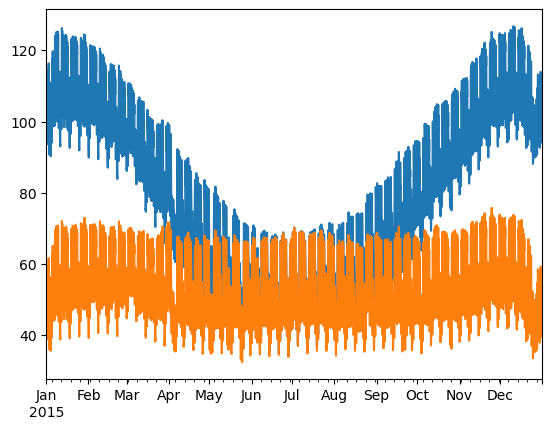

In [40]:
plt.figure()
df_new_time_series['load [GW]'].plot()
df_time_series['load [GW]'].plot()

#### Optimal Alpha value change?

The optimal value for wind generation changes from 60% to 85%. This is evident in the change of load profile with increased peaks in the " winter months" and would require more discharge during these months. See figure above

## (III) Designing a Run-of-River Power Plant

#### Read dataset as pandas.Series

In [41]:
url_run_of_river = "https://tubcloud.tu-berlin.de/s/af5G99i35dwNPCz/download/water-flows.csv"
series_run_of_river = pd.read_csv(url_run_of_river, index_col=0, parse_dates=True)["Scaled Flow"]

# Assert index as DatetimeIndex
assert type(series_run_of_river.index) == pd.DatetimeIndex
print("Type of index:", type(series_run_of_river.index))
series_run_of_river.head()

Type of index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


Date
1983-01-01    1.445017
1983-01-02    1.808810
1983-01-03    3.476350
1983-01-04    1.963007
1983-01-05    4.854887
Name: Scaled Flow, dtype: float64

#### Monthly resampled mean flow rate

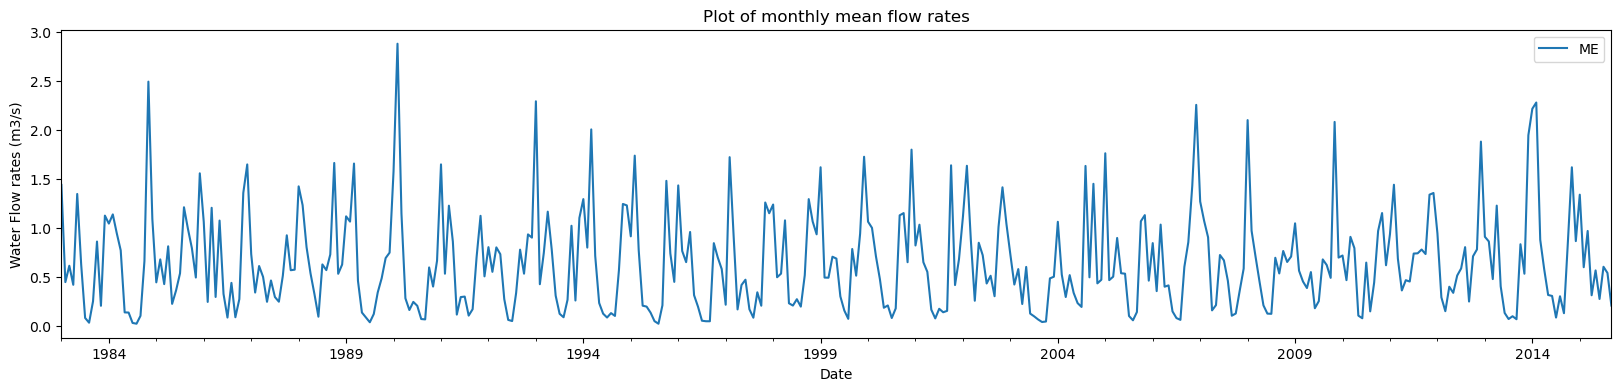

In [42]:
# for c in series_run_of_river.columns:
fig, ax = plt.subplots(figsize =(20,4))
for res in ["ME"]:
    series_run_of_river.resample(res).mean().plot(ax=ax, label=res)
ax.set_ylabel('Water Flow rates (m3/s)')
ax.set_xlabel('Date')
ax.set_title("Plot of monthly mean flow rates")
plt.legend()

#### Compensation Flow

In [43]:
# Compensation flow assume the 7% quantile of flows
compensation_flow = series_run_of_river.quantile(q = 0.07,interpolation='linear')     
print(f" The compensation flow for the run of river plant is {compensation_flow:.4f}")

 The compensation flow for the run of river plant is 0.0640


#### Design Flow

In [44]:
# Design flow assume the 80% quantile of flows
design_flow = series_run_of_river.quantile(q = 0.8, interpolation='linear')
print(f" The compensation flow for the run of river plant is {design_flow:.4f}")

 The compensation flow for the run of river plant is 0.9612


#### Times series for available flow for power production

In [45]:
df_run_of_river = pd.DataFrame({
    'scaled_flow': series_run_of_river
})

In [46]:
for index, row in df_run_of_river.iterrows():
    available_flow = row['scaled_flow'] - compensation_flow
    if available_flow > design_flow:
        df_run_of_river.at[index, 'available_flow'] = design_flow
    else:
        df_run_of_river.at[index, 'available_flow'] = available_flow

In [47]:
df_run_of_river

,scaled_flow,available_flow
Date,,
1983-01-01,1.445017,0.961190
1983-01-02,1.808810,0.961190
1983-01-03,3.476350,0.961190
1983-01-04,1.963007,0.961190
1983-01-05,4.854887,0.961190
...,...,...
2015-09-26,0.178665,0.114660
2015-09-27,0.163430,0.099425
2015-09-28,0.151888,0.087883


In [48]:
df_run_of_river_sorted = df_run_of_river['scaled_flow'].sort_values(ascending=False)

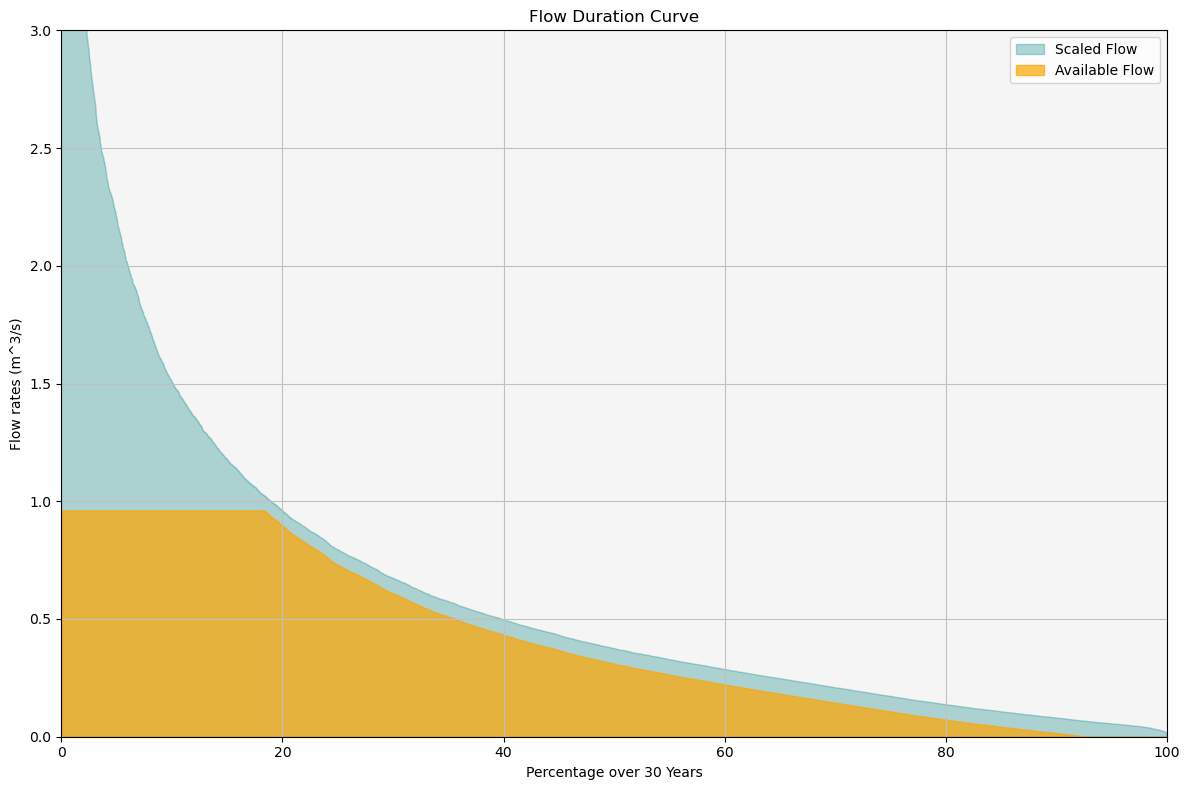

In [49]:
# Example DataFrame (replace with your actual data)
# Sort the DataFrame by scaled_flow for load duration curve
df_run_of_river_sorted = df_run_of_river.sort_values(by='scaled_flow', ascending=False).reset_index(drop=True)
scaled_flow_percentage = df_run_of_river_sorted.index / len(df_run_of_river_sorted) * 100

# Sort the DataFrame by available_flow for available flow duration curve
df_available_flow_sorted = df_run_of_river.sort_values(by='available_flow', ascending=False).reset_index(drop=True)
available_flow_percentage = df_run_of_river_sorted.index / len(df_run_of_river_sorted) * 100

# Create the plot
plt.figure(figsize=(12, 8))

# Plot Load Duration Curve
plt.fill_between(scaled_flow_percentage, df_run_of_river_sorted['scaled_flow'], label='Scaled Flow', color='teal', alpha=0.3)

# Plot Available Flow Duration Curve
plt.fill_between(available_flow_percentage, df_available_flow_sorted['available_flow'], label='Available Flow', color='orange', alpha=0.7)

# Customize plot appearance
plt.title('Flow Duration Curve')
plt.xlabel('Percentage over 30 Years')
plt.ylabel('Flow rates (m^3/s)')
plt.xlim(0, 100)
plt.ylim(0, 3)# max(df_run_of_river_sorted['scaled_flow'].max(), df_available_flow_sorted['available_flow'].max()) * 1.1)
plt.legend()
plt.grid(True, color='silver')
plt.gca().set_facecolor('whitesmoke')

plt.tight_layout()
plt.show()


#### Determine the rated power of the run-of-river scheme using the design flow.

In [50]:
η = 0.92
ρ = 1000
g = 9.81
H = 48
Q = design_flow
rated_power = η * ρ * g * H * Q

print(f"The rated power is {rated_power:.2f} kW")

The rated power is 416396.74 kW


#### Compute a time series for the daily electricity production in kWh of the scheme based on the available flows.

In [51]:
# Annual Energy production
η = 0.92
ρ = 1000
g = 9.81
H = 48
Q = df_run_of_river['available_flow']

E = η * ρ * g * H * Q

df_run_of_river['electricity_production_[kWh]'] = E

# Displayresults
df_run_of_river.head()

,scaled_flow,available_flow,electricity_production_[kWh]
Date,,,
1983-01-01,1.445017,0.96119,416396.735424
1983-01-02,1.808810,0.96119,416396.735424
1983-01-03,3.476350,0.96119,416396.735424
1983-01-04,1.963007,0.96119,416396.735424
1983-01-05,4.854887,0.96119,416396.735424


#### What is the long-term average capacity factor of the run-of-river power plant?

In [52]:
capacity_factor_average = df_run_of_river['electricity_production_[kWh]'].mean() / df_run_of_river['electricity_production_[kWh]'].max()

print(f"The long-term average capacity factor of the run-of-river power plant is {capacity_factor_average:.2f} kW")

The long-term average capacity factor of the run-of-river power plant is 0.43 kW


#### Compute and plot the annual energy yields of the plant for the years 1983 to 2014.

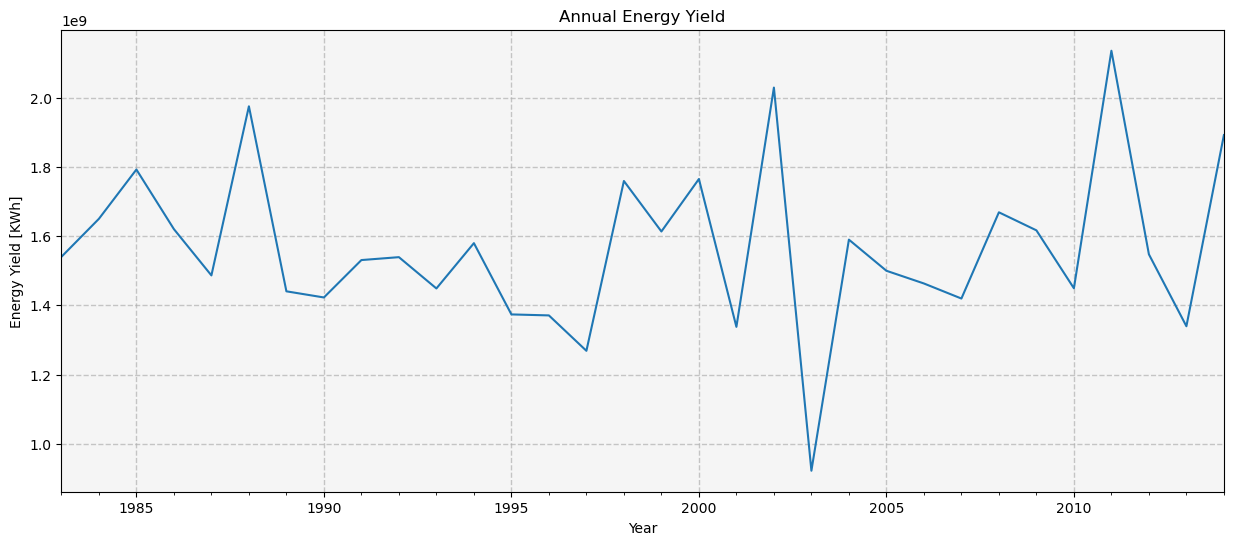

In [53]:
annual_energy_yield = df_run_of_river['electricity_production_[kWh]'].resample('Y').sum()*24

# Plotting
plt.figure(figsize=(15, 6)).add_subplot().set_facecolor('whitesmoke')
annual_energy_yield.loc[:'2014-12-31'].plot(ylabel = 'Energy Yield [KWh]', xlabel = 'Year', title = 'Annual Energy Yield')

# Adding labels and grid
plt.ylabel('Energy Yield [KWh]')
plt.xlabel('Year')
plt.title('Annual Energy Yield')
plt.grid(linestyle='--', linewidth=1, alpha=0.7)

#### Compute and plot the relative deviation of the annual energy yields from the long-term average annual energy yield.

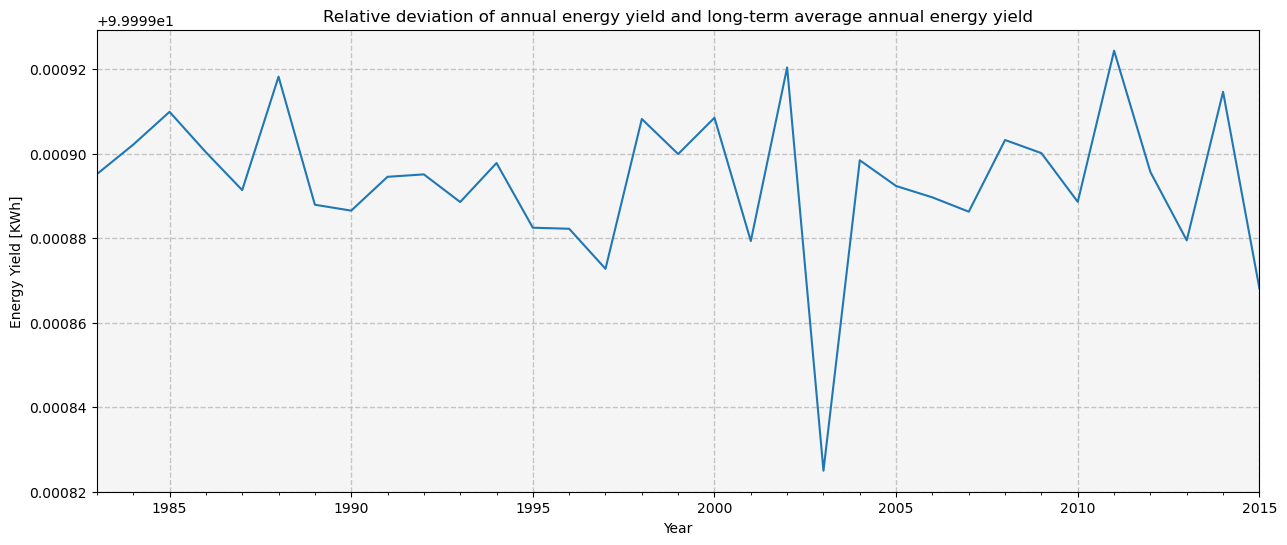

In [54]:
# Compute for whole year
total_hours = 24*365
annual_energy_yield_longterm = capacity_factor_average * capacity_factor_average * total_hours

relative_deviation = (annual_energy_yield - annual_energy_yield_longterm) / annual_energy_yield*100

# Plotting
plt.figure(figsize=(15, 6)).add_subplot().set_facecolor('whitesmoke')
relative_deviation.plot()

# Adding labels and grid
plt.ylabel('Energy Yield [KWh]')
plt.xlabel('Year')
plt.title('Relative deviation of annual energy yield and long-term average annual energy yield')
plt.grid(linestyle='--', linewidth=1, alpha=0.7)